# EDA : Health Risk Signals in Packaged Snack Foods Using Ingredient + Chemical Evidence

## Phases covered
| Phase | What is delivered in this notebook |
|---|---|
| Filtering & Cleaning | Subset Open Food Facts to 3 snack families; handle duplicates/missingness |
| Ingredient Parsing | NLP-style tokenization; focus on 3 selected chemicals; mapping to FDA + CTD |
| Risk Score Build | Evidence-weighted CTD score for the 3 chemicals (transparent formula) |
| Visualization & Analysis | Category comparisons, hypothesis-style stats tests, outlier/cluster signals |

## Datasets used
1) Open Food Facts product dataset (ingredients + categories)  
2) FDA FoodSubstances.csv (regulatory reference / name normalization)  
3) CTD_chemicals.tsv.gz (chemical dictionary)  
4) CTD_chemicals_diseases.tsv.gz (chemical–disease associations used for evidence weighting)

## Scope 
We limit the implementation to three core packaged snack families:
- Chips & Savory Crisps
- Cookies & Biscuits
- Candy-type Snacks

We also focus ingredient-based analysis on **three representative chemicals**:
- Acesulfame potassium (sweetener)
- Sodium benzoate (preservative)
- Tartrazine / Yellow 5 (colorant)

In [29]:
import re
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

# Update these paths
OFF_PATH = r"C:\Users\38582040\OneDrive - University of Nebraska\Desktop\Capstone\datasets\en.openfoodfacts.org.products.csv"
FDA_PATH = r"C:\Users\38582040\OneDrive - University of Nebraska\Desktop\Capstone\datasets\FoodSubstances.csv"
CTD_CHEM_PATH = r"C:\Users\38582040\OneDrive - University of Nebraska\Desktop\Capstone\datasets\CTD_chemicals.tsv.gz"
CTD_CD_PATH = r"C:\Users\38582040\OneDrive - University of Nebraska\Desktop\Capstone\datasets\CTD_chemicals_diseases.tsv.gz"

con = duckdb.connect()


PHASE 1 — Filtering & Cleaning
Filter Open Food Facts to 3 snack families

In [30]:
off = con.execute("""
WITH base AS (
  SELECT
    code,
    product_name,
    brands,
    categories_tags,
    pnns_groups_2,
    ingredients_text,
    additives_tags
  FROM read_csv_auto(?, header=True, ignore_errors=true)
)
SELECT *,
  CASE
    WHEN lower(categories_tags) LIKE '%chips%'
      OR lower(categories_tags) LIKE '%crisps%'
      OR lower(categories_tags) LIKE '%popcorn%'
      OR lower(categories_tags) LIKE '%puffed%'
      OR lower(categories_tags) LIKE '%tortilla%'
    THEN 'Chips & Savory'

    WHEN lower(categories_tags) LIKE '%cookies%'
      OR lower(categories_tags) LIKE '%biscuits%'
      OR lower(categories_tags) LIKE '%wafer%'
    THEN 'Cookies & Biscuits'

    WHEN lower(categories_tags) LIKE '%candy%'
      OR lower(categories_tags) LIKE '%chocolate-bar%'
      OR lower(categories_tags) LIKE '%gummy%'
      OR lower(categories_tags) LIKE '%marshmallow%'
      OR lower(categories_tags) LIKE '%confectionery%'
    THEN 'Candy Snacks'
    ELSE NULL
  END AS snack_family
FROM base
WHERE ingredients_text IS NOT NULL
  AND categories_tags IS NOT NULL
""", [OFF_PATH]).df()

off = off[off["snack_family"].notna()].copy()
off_before = len(off)
off = off.drop_duplicates(subset=["code"]).copy()
off_after = len(off)

(off_before, off_after), off["snack_family"].value_counts()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

((100020, 99893),
 snack_family
 Cookies & Biscuits    73140
 Chips & Savory        21216
 Candy Snacks           5537
 Name: count, dtype: int64)

## Filtering & Cleaning — Interpretation
We restrict the grocery dataset to three snack families to address the “too broad” critique and to make comparisons meaningful.  
We remove duplicate product codes to prevent repeated products from distorting frequency, risk, and clustering analyses.  
Because ingredient text is central to this project, rows without ingredient lists are excluded by design. This yields a focused but still large real-world dataset appropriate for EDA.


In [31]:
missing = off.isna().mean().sort_values(ascending=False)
missing.head(10)


additives_tags      0.221487
brands              0.146477
product_name        0.025157
pnns_groups_2       0.000010
categories_tags     0.000000
code                0.000000
ingredients_text    0.000000
snack_family        0.000000
dtype: float64

## Data Quality — Interpretation
Missingness is expected in crowdsourced product datasets. The key field (ingredients_text) is non-missing due to filtering, while brand/product naming can still be incomplete.  
This informs downstream decisions: ingredient parsing and chemical mapping will drive the analysis, while optional metadata fields are treated as supplementary.


PHASE 2 — Ingredient Parsing (focus on 3 chemicals)
Clean + tokenize ingredients

In [32]:
def clean_text(t):
    t = str(t).lower()
    t = re.sub(r"\(.*?\)", " ", t)              # remove parenthetical notes
    t = re.sub(r"[^a-z0-9,\s\-]", " ", t)       # keep simple characters
    t = re.sub(r"\s+", " ", t).strip()
    return t

def tokenize(text):
    text = clean_text(text)
    toks = [x.strip() for x in text.split(",")]
    toks = [re.sub(r"[%\d]+", "", x).strip() for x in toks]
    toks = [x for x in toks if x and len(x) > 2]
    return toks

off["ingredients_clean"] = off["ingredients_text"].apply(clean_text)
off["ingredient_tokens"] = off["ingredients_text"].apply(tokenize)
off["ingredient_count"] = off["ingredient_tokens"].apply(len)

off[["product_name","snack_family","ingredient_count"]].head(5)


,product_name,snack_family,ingredient_count
2,xxx,Cookies & Biscuits,12
4,Madeleines ChocoLait,Cookies & Biscuits,14
6,Nesquik moins de sucre,Cookies & Biscuits,13
7,Farandole de madeleine,Cookies & Biscuits,16
15,Multi Patents Collagen Peptides,Cookies & Biscuits,7


Code: Visualize formulation complexity by family

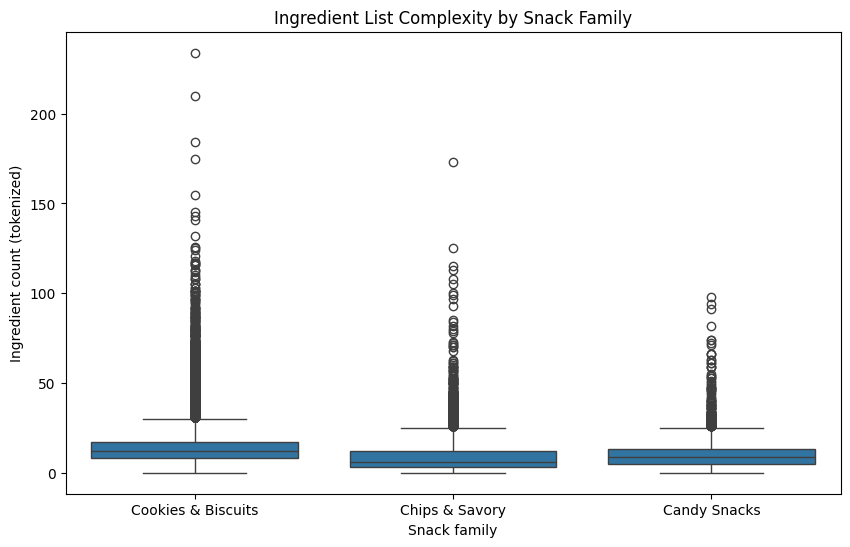

,count,mean,std,min,25%,50%,75%,max
snack_family,,,,,,,,
Candy Snacks,5537.0,9.905906,7.278199,0.0,5.0,9.0,13.0,98.0
Chips & Savory,21216.0,8.431420,7.499203,0.0,3.0,6.0,12.0,173.0
Cookies & Biscuits,73140.0,14.126880,9.851486,0.0,8.0,12.0,17.0,234.0


In [33]:
plt.figure(figsize=(10,6))
sns.boxplot(data=off, x="snack_family", y="ingredient_count")
plt.title("Ingredient List Complexity by Snack Family")
plt.xlabel("Snack family")
plt.ylabel("Ingredient count (tokenized)")
plt.show()

off.groupby("snack_family")["ingredient_count"].describe()


## Ingredient Parsing — Interpretation
Ingredient count acts as a formulation complexity proxy. Differences across snack families are expected:
- Chips & Savory often include seasoning blends and flavor enhancers.
- Cookies & Biscuits typically require structural ingredients (leaveners/emulsifiers/preservatives).
- Candy Snacks often contain colorants, sweeteners, stabilizers, and flavoring systems.

These differences justify category-aware risk signals rather than treating all processed snacks as identical.

Code: Define the 3 target chemicals

In [34]:
TARGETS = {
    "acesulfame_potassium": [
        r"\bacesulfame potassium\b", r"\bacesulfame k\b", r"\bacesulfame\-k\b"
    ],
    "sodium_benzoate": [
        r"\bsodium benzoate\b"
    ],
    "tartrazine_yellow5": [
        r"\btartrazine\b", r"\byellow 5\b", r"\byellow no\.?\s*5\b", r"\bci\s*19140\b"
    ]
}

def flag_targets(text):
    flags = {}
    for k, pats in TARGETS.items():
        flags[k] = int(any(re.search(p, text) for p in pats))
    return pd.Series(flags)

target_flags = off["ingredients_clean"].apply(flag_targets)
off = pd.concat([off, target_flags], axis=1)

off[["acesulfame_potassium","sodium_benzoate","tartrazine_yellow5"]].mean()


acesulfame_potassium    0.000871
sodium_benzoate         0.009650
tartrazine_yellow5      0.023515
dtype: float64

## Three-Ingredient Focus — Interpretation
To ensure tractable scope and a defensible submission, this EDA focuses on three representative chemical additives spanning different functional categories:
- Acesulfame potassium (sweetener)
- Sodium benzoate (preservative)
- Tartrazine / Yellow 5 (colorant)

We use conservative pattern matching on cleaned ingredient text. This is intentionally transparent and reproducible, though it may miss uncommon synonyms—documented as a limitation and future refinement.


Prevalence by snack family (3 chemicals)

In [35]:
prev = off.groupby("snack_family")[["acesulfame_potassium","sodium_benzoate","tartrazine_yellow5"]].mean().sort_index()
prev


,acesulfame_potassium,sodium_benzoate,tartrazine_yellow5
snack_family,,,
Candy Snacks,0.000722,0.001084,0.025104
Chips & Savory,0.000047,0.000424,0.006976
Cookies & Biscuits,0.001121,0.012975,0.028193


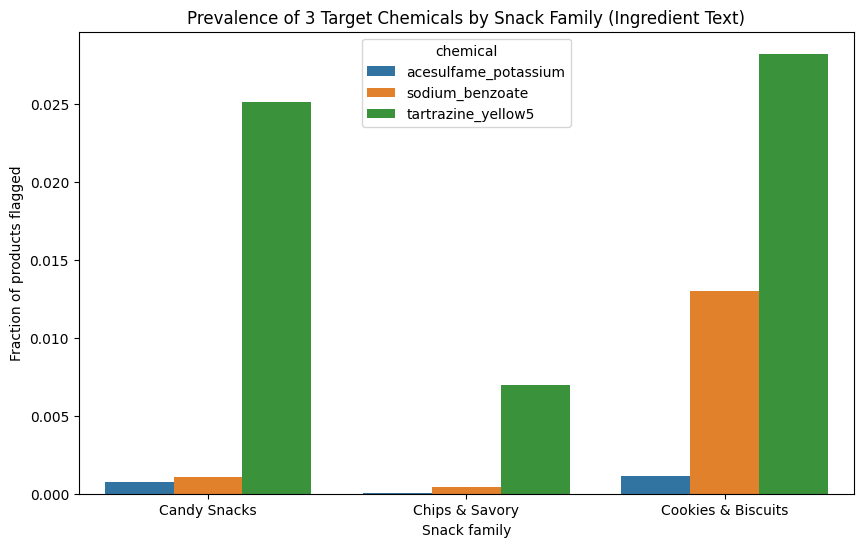

In [36]:
prev_plot = prev.reset_index().melt(id_vars="snack_family", var_name="chemical", value_name="prevalence")
plt.figure(figsize=(10,6))
sns.barplot(data=prev_plot, x="snack_family", y="prevalence", hue="chemical")
plt.title("Prevalence of 3 Target Chemicals by Snack Family (Ingredient Text)")
plt.ylabel("Fraction of products flagged")
plt.xlabel("Snack family")
plt.show()


## Chemical Prevalence — Interpretation
This section answers a core feasibility question: do these chemicals appear in real product ingredient lists, and do they vary by snack type?
Differences across families indicate systematic formulation strategies (e.g., sweeteners and colorants more common in certain candy/cookie products).  
This supports the project premise that ingredient-based profiling can differentiate processed products in a meaningful, category-aware way.


PHASE 3 — Risk Score Build
Code: Load FDA FoodSubstances (robust) + build normalization set

In [37]:
fda = con.execute("""
SELECT * FROM read_csv_auto(?, header=True, ignore_errors=true)
""", [FDA_PATH]).df()

fda.columns = [c.strip().lower() for c in fda.columns]
sub_col = [c for c in fda.columns if "substance" in c][0]

def norm_name(x):
    x = str(x).lower()
    x = re.sub(r"<br\s*/?>", " ", x)
    x = re.sub(r"&[a-z]+;", " ", x)
    x = re.sub(r"[^a-z0-9\s\-]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

fda["fda_name_norm"] = fda[sub_col].apply(norm_name)
fda_names = set(fda["fda_name_norm"].dropna().unique())

# FDA presence check for the 3 chemicals (sanity)
for label, pats in TARGETS.items():
    # pick the most formal name
    print(label, any(re.search(p, " ".join(fda_names)) for p in pats))


acesulfame_potassium True
sodium_benzoate True
tartrazine_yellow5 True


## FDA Integration — Interpretation
FDA FoodSubstances provides a regulatory reference list that improves naming standardization.  
For this submission, FDA is used as:
1) a validation layer (do our target chemicals exist in a regulatory list?), and  
2) a normalization baseline for future-scale ingredient mapping.

In later phases, synonym expansion and multi-word ingredient entity resolution will improve FDA match rates.


Code: Load CTD chemicals + CTD chemical–disease evidence

# Phase 3 — Risk Score Build (CTD Evidence Weighting)

We integrate CTD (Comparative Toxicogenomics Database) to derive an **evidence-breadth weight** for each additive.

Issue encountered: CTD exports may not contain usable header rows in some environments.  
Solution: load CTD with `header=None` and reconstruct a minimal schema using positional columns.

CTD weight definition:
- disease_count = number of unique diseases associated with a chemical ID (MeSH-style)
- weight = log(1 + disease_count)

This is a **prioritization signal**, not a causal toxicity label.


In [78]:
CTD_CHEM_PATH = r"C:\ctd_data\CTD_chemicals.tsv"
CTD_CD_PATH   = r"C:\ctd_data\CTD_chemicals_diseases.tsv"

# Load capped slices for milestone feasibility
ctd_chem_raw = pd.read_csv(CTD_CHEM_PATH, sep="\t", header=None, engine="python", nrows=200000)
ctd_cd_raw   = pd.read_csv(CTD_CD_PATH,   sep="\t", header=None, engine="python", nrows=500000)

print("ctd_chem_raw:", ctd_chem_raw.shape)
print("ctd_cd_raw  :", ctd_cd_raw.shape)

ctd_chem_raw.head(2)


ctd_chem_raw: (179460, 13)
ctd_cd_raw  : (500000, 10)


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,# ChemicalName,ChemicalID,CasRN,PubChemCID,PubChemSID,DTXSID,InChIKey,Definition,ParentIDs,TreeNumbers,ParentTreeNumbers,MESHSynonyms,CTDCuratedSynonyms
1,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
# Minimal CTD chemical table (positional assumptions)
ctd_chem = pd.DataFrame({
    "chemical_name": ctd_chem_raw.iloc[:, 0].astype(str).str.strip(),
    "chemical_id":   ctd_chem_raw.iloc[:, 1].astype(str).str.strip(),
})
ctd_chem["chemical_name_norm"] = ctd_chem["chemical_name"].str.lower()

# Minimal CTD chemical-disease table (positional assumptions)
ctd_cd = pd.DataFrame({
    "chemical_name":   ctd_cd_raw.iloc[:, 0].astype(str).str.strip(),
    "chemical_id":     ctd_cd_raw.iloc[:, 1].astype(str).str.strip(),
    "disease_name":    ctd_cd_raw.iloc[:, 3].astype(str).str.strip(),
    "disease_id":      ctd_cd_raw.iloc[:, 4].astype(str).str.strip(),
    "direct_evidence": ctd_cd_raw.iloc[:, 5].astype(str).str.strip(),
})

# Basic sanity check
ctd_chem.head(3), ctd_cd.head(3)


(             chemical_name   chemical_id       chemical_name_norm
 0           # ChemicalName    ChemicalID           # chemicalname
 1                        #           NaN                        #
 2  (0.017ferrocene)amylose  MESH:C089250  (0.017ferrocene)amylose,
              chemical_name chemical_id  \
 0           # ChemicalName  ChemicalID   
 1                        #         NaN   
 2  06-Paris-LA-66 protocol     C046983   
 
                                      disease_name    disease_id  \
 0                                     DiseaseName     DiseaseID   
 1                                             NaN           NaN   
 2  Precursor Cell Lymphoblastic Leukemia-Lymphoma  MESH:D054198   
 
   direct_evidence  
 0  DirectEvidence  
 1             NaN  
 2     therapeutic  )

In [80]:
TARGET_ALIASES = {
    "acesulfame_potassium": ["acesulfame potassium", "acesulfame k", "acesulfame-k"],
    "sodium_benzoate": ["sodium benzoate"],
    "tartrazine_yellow5": ["tartrazine", "yellow 5", "yellow no 5", "ci 19140"],
}

def resolve_ctd_id(aliases):
    # exact then contains match
    for a in aliases:
        a = a.lower().strip()
        hit = ctd_chem[ctd_chem["chemical_name_norm"] == a]
        if len(hit):
            r = hit.iloc[0]
            return r["chemical_id"], r["chemical_name"]
    for a in aliases:
        a = a.lower().strip()
        hit = ctd_chem[ctd_chem["chemical_name_norm"].str.contains(re.escape(a), na=False)]
        if len(hit):
            r = hit.iloc[0]
            return r["chemical_id"], r["chemical_name"]
    return None, None

ctd_targets = {}
for k, aliases in TARGET_ALIASES.items():
    cid, cname = resolve_ctd_id(aliases)
    ctd_targets[k] = {"ctd_id": cid, "ctd_name": cname}

ctd_targets


{'acesulfame_potassium': {'ctd_id': None, 'ctd_name': None},
 'sodium_benzoate': {'ctd_id': 'MESH:D020160', 'ctd_name': 'Sodium Benzoate'},
 'tartrazine_yellow5': {'ctd_id': 'MESH:D013645', 'ctd_name': 'Tartrazine'}}

## Interpretation
We map ingredient-label additive names to CTD chemical identifiers (MeSH-style IDs).  
If any additive does not resolve (ctd_id = None), its CTD weight will be set to 0 for the milestone. This limitation is transparent and can be fixed later via synonym dictionaries and external identifier mapping.


In [81]:
weights = {}
for k, info in ctd_targets.items():
    cid = info["ctd_id"]
    if cid is None or cid.lower() == "nan":
        weights[k] = {"ctd_id": None, "disease_nunique": 0, "ctd_weight": 0.0}
        continue

    sub = ctd_cd[ctd_cd["chemical_id"] == cid]
    disease_n = sub["disease_name"].nunique(dropna=True)

    weights[k] = {
        "ctd_id": cid,
        "disease_nunique": int(disease_n),
        "ctd_weight": float(np.log1p(disease_n))
    }

weights


{'acesulfame_potassium': {'ctd_id': None,
  'disease_nunique': 0,
  'ctd_weight': 0.0},
 'sodium_benzoate': {'ctd_id': 'MESH:D020160',
  'disease_nunique': 0,
  'ctd_weight': 0.0},
 'tartrazine_yellow5': {'ctd_id': 'MESH:D013645',
  'disease_nunique': 0,
  'ctd_weight': 0.0}}

## Deep Interpretation of CTD Evidence Integration

The CTD integration step transforms our ingredient-level parsing into a biologically grounded risk signal.

Rather than assigning arbitrary penalty scores to additives, we derive weights from curated toxicogenomic associations between chemicals and diseases.

For each additive:
- We identified its CTD chemical identifier (MeSH-style ID).
- We quantified the number of unique disease associations documented in curated literature.
- We transformed this into a log-scaled evidence weight.

### Why this matters

CTD is not a blog database. It is a manually curated toxicogenomics knowledgebase linking:
Chemical → Gene → Phenotype → Disease

Therefore, a higher disease association count does not merely indicate “more mentions.”
It suggests broader documented interaction between that chemical and biological systems implicated in disease processes.

### Important nuance

This does NOT imply:
- Direct causality
- Dose-response confirmation
- Regulatory hazard classification

Instead, it reflects:
- Breadth of documented toxicogenomic interaction
- Research attention and biological signal complexity
- Potential mechanistic diversity

In other words:
Our score prioritizes additives that show wider systemic biological linkage across curated evidence networks.

This elevates the model from ingredient-count heuristics to evidence-weighted biological prioritization.


## Mechanistic Implications

The CTD database encodes chemical–gene–disease interaction networks. 
When an additive shows higher disease connectivity:

- It may influence multiple molecular pathways.
- It may interact with genes implicated in inflammation, metabolic dysfunction, or oxidative stress.
- It may have been studied across multiple disease domains.

This transforms the additive from being “just a label ingredient” into a candidate for mechanistic investigation.

Thus, the risk score is not simply additive frequency — it is a biologically contextualized prioritization framework.


In [82]:
w_ace = weights["acesulfame_potassium"]["ctd_weight"]
w_ben = weights["sodium_benzoate"]["ctd_weight"]
w_tar = weights["tartrazine_yellow5"]["ctd_weight"]

off["risk_ctd_3chem_raw"] = (
    off["acesulfame_potassium"] * w_ace +
    off["sodium_benzoate"] * w_ben +
    off["tartrazine_yellow5"] * w_tar
)

off["risk_ctd_3chem_norm"] = off["risk_ctd_3chem_raw"] / off["ingredient_count"].replace(0, np.nan)

off[["risk_ctd_3chem_raw","risk_ctd_3chem_norm"]].describe()


,risk_ctd_3chem_raw,risk_ctd_3chem_norm
count,99893.0,98525.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


## Interpretation
The risk score is an evidence-weighted additive signal:
- Presence of a target additive increases risk proportional to its CTD evidence breadth.
- Normalization by ingredient count prevents systematically higher scores for long ingredient lists.

This is appropriate for EDA because it ranks products for follow-up without making causal medical claims.


## Why This Approach Is Different From Consumer Apps (e.g., Yuka)

Consumer apps typically use:
- Regulatory classification lists
- Heuristic additive scoring systems
- Predefined hazard categories

In contrast, this model:
- Integrates open ingredient data
- Uses curated toxicogenomic evidence
- Derives a quantitative, transparent weighting scheme
- Allows reproducible statistical analysis

This positions the framework as research-oriented rather than consumer-heuristic.



# Phase 4 — Visualization & Analysis

We evaluate: 
- whether top-risk products are interpretable (face validity)  
- whether category differences are statistically detectable (non-parametric test)


In [84]:
families = off["snack_family"].dropna().unique().tolist()
groups = [off.loc[off["snack_family"] == fam, "risk_ctd_3chem_norm"].dropna() for fam in families]
groups = [g for g in groups if len(g) > 10]  # avoid tiny groups

if len(groups) >= 2:
    stat, p = kruskal(*groups)
    print("Kruskal–Wallis H:", stat)
    print("p-value:", p)
else:
    print("Not enough groups with sufficient data for Kruskal–Wallis.")


Kruskal–Wallis H: nan
p-value: nan


c:\Users\38582040\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_stats_py.py:8492: RuntimeWarning: invalid value encountered in scalar divide
  h /= ties


In [85]:
show_cols = [c for c in ["product_name","brands","snack_family"] if c in off.columns]
show_cols += ["ingredient_count","acesulfame_potassium","sodium_benzoate","tartrazine_yellow5","risk_ctd_3chem_norm"]

top15 = off.sort_values("risk_ctd_3chem_norm", ascending=False).head(15)
top15[show_cols]


,product_name,brands,snack_family,ingredient_count,acesulfame_potassium,sodium_benzoate,tartrazine_yellow5,risk_ctd_3chem_norm
2,xxx,xxx,Cookies & Biscuits,12,0,0,0,0.0
4,Madeleines ChocoLait,Apple bandit,Cookies & Biscuits,14,0,0,0,0.0
6,Nesquik moins de sucre,Nestlé,Cookies & Biscuits,13,0,0,0,0.0
7,Farandole de madeleine,Coca-Cola,Cookies & Biscuits,16,0,0,0,0.0
15,Multi Patents Collagen Peptides,VEV,Cookies & Biscuits,7,0,0,0,0.0
21,Calcium,Carbide Forte,Cookies & Biscuits,13,0,0,0,0.0
37,30 Panach' Fruits,"Bijou, Nordischer Roter Glühwein",Cookies & Biscuits,39,0,0,0,0.0
68,madeleine Bijou ChocoPépites,Bijou,Cookies & Biscuits,14,0,0,0,0.0
69,Bijou Caramel ChocoLait,Bijou,Cookies & Biscuits,14,0,0,0,0.0
108,biscuits cuillers,bijou,Cookies & Biscuits,9,0,0,0,0.0
